# Agent.py

In [ ]:
import os
import sys
from typing import Literal

from langchain_classic.agents import AgentExecutor, create_tool_calling_agent
from pydantic import BaseModel, Field
from langchain.tools import tool
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from dotenv import load_dotenv

load_dotenv()


#STRUCTURED OUTPUT SCHEMA
class AgentResponse(BaseModel):
    """Структурированный ответ маркетингового агента"""

    result: str = Field(description="Основной результат анализа или рекомендации")
    confidence: float = Field(ge=0.0, le=1.0, description="Уверенность в ответе от 0 до 1")
    reasons: list[str] = Field(description="Причины и обоснования для рекомендаций")
    risk_level: Literal["НИЗКИЙ", "СРЕДНИЙ", "ВЫСОКИЙ"] = Field(
        description="Уровень риска для предложенной стратегии"
    )
    analysis_type: list[str] = Field(
        description="Типы анализа, которые были применены (например: аудитория, контент, конкуренты)"
    )


#SKILLS СИСТЕМА
BASE_PROMPT = """Ты — профессиональный маркетолог и аналитик.
Помогаешь с анализом целевой аудитории, разработкой контент-стратегий и маркетинговых кампаний.
Используй инструменты для получения данных.
Отвечай на русском языке, структурированно и аргументированно."""

SKILLS: dict[str, str] = {
    "audience_analysis": """[Skill: Анализ целевой аудитории]
При анализе ЦА учитывай:
- Демографические характеристики (возраст, пол, география)
- Психографические параметры (интересы, ценности, образ жизни)
- Боли и потребности аудитории
- Платформы присутствия и паттерны поведения
- Готовность к покупке и средний чек""",

    "content_strategy": """[Skill: Контент-стратегия]
При разработке контент-плана учитывай:
- Цели контента (вовлечение, продажи, узнаваемость)
- Форматы под конкретные платформы
- Частоту публикаций и оптимальное время
- Баланс между образовательным, развлекательным и продающим контентом
- Метрики эффективности (охват, вовлечение, конверсия)""",

    "risk_assessment": """[Skill: Оценка рисков]
Анализируй потенциальные риски:
- Репутационные риски
- Финансовые риски и ROI
- Конкурентные угрозы
- Сезонность и рыночные тренды
- Технические ограничения платформ""",

    "competitive_analysis": """[Skill: Конкурентный анализ]
При анализе конкурентов оценивай:
- Позиционирование и УТП
- Контент-стратегию и форматы
- Уровень вовлечённости аудитории
- Ценообразование и акционные механики
- Слабые стороны, которые можно использовать""",

    "expert_mode": """[Skill: Экспертный режим]
Давай развёрнутые ответы с:
- Примерами из практики
- Конкретными метриками и KPI
- Пошаговыми инструкциями
- Альтернативными подходами
- Референсами на успешные кейсы"""
}

SKILL_KEYWORDS: dict[str, list[str]] = {
    "audience_analysis": ["ца", "аудитор", "демограф", "сегмент", "персона"],
    "content_strategy": ["контент", "пост", "публикац", "стратег", "план"],
    "risk_assessment": ["риск", "угроз", "безопасн", "проблем"],
    "competitive_analysis": ["конкурент", "рынок", "анализ рынка"],
    "expert_mode": ["подробно", "детально", "экспертн", "развёрнуто"]
}


def detect_skills(query: str) -> list[str]:
    """Определяет подходящие Skills по ключевым словам"""
    query_lower = query.lower()
    return [
        skill
        for skill, keywords in SKILL_KEYWORDS.items()
        if any(kw in query_lower for kw in keywords)
    ]


def build_system_prompt(skills: list[str]) -> str:
    """Собирает системный промпт с активными Skills"""
    parts = [BASE_PROMPT]
    for skill_name in skills:
        if skill_name in SKILLS:
            parts.append(SKILLS[skill_name])
    return "\n\n".join(parts)


#ИНСТРУМЕНТЫ
@tool
def analyze_audience(niche: str) -> str:
    """Анализирует целевую аудиторию по нише (фитнес, IT, handmade, b2b, кулинария)"""
    audiences = {
        "фитнес": "ЦА: женщины 25-35 лет, средний доход. Интересы: ЗОЖ, спорт, красота. Боли: лишний вес, нехватка мотивации, дефицит времени. Платформы: Instagram (Stories, Reels), TikTok, YouTube. Средний чек: 3000-8000₽",
        "it": "ЦА: 20-30 лет, преимущественно мужчины. Интересы: технологии, карьера, саморазвитие. Боли: выгорание, смена профессии, нехватка практики. Платформы: Telegram, YouTube, Habr. Средний чек: 15000-50000₽",
        "handmade": "ЦА: женщины 30-45 лет, средний+ доход. Интересы: рукоделие, уникальные подарки, хобби. Боли: нехватка времени, поиск материалов, монетизация хобби. Платформы: Pinterest, Instagram, Ярмарка Мастеров. Средний чек: 1500-5000₽",
        "b2b": "ЦА: руководители и собственники 30-50 лет. Интересы: оптимизация бизнеса, автоматизация, масштабирование. Боли: неэффективные процессы, нехватка клиентов, высокие издержки. Платформы: LinkedIn, Telegram, email-рассылки. Средний чек: 50000-500000₽",
        "кулинария": "ЦА: женщины 25-45 лет, семейные. Интересы: быстрые рецепты, здоровое питание, семейные ужины. Боли: нехватка идей для меню, ограниченное время, детское питание. Платформы: YouTube, Instagram, Pinterest. Средний чек: 800-3000₽"
    }
    return audiences.get(niche.lower(), f"Ниша '{niche}' не найдена. Доступные: фитнес, IT, handmade, b2b, кулинария")


@tool
def generate_post_ideas(theme: str) -> str:
    """Генерирует идеи постов по теме (запуск, вовлечение, продажи, экспертность)"""
    ideas = {
        "запуск": "1) Тизер с обратным отсчётом и закулисьем разработки\n2) Инструкция по использованию с видео-демо\n3) История создания: почему и для кого\n4) Ранний доступ для первых 50 пользователей\n5) Сравнение «до» и «после» использования продукта",
        "вовлечение": "1) Опрос: какую функцию хотите видеть в следующем обновлении?\n2) Челлендж на 30 дней с ежедневными заданиями\n3) Конкурс с призами: поделитесь своим опытом\n4) Голосование за выбор нового дизайна\n5) Q&A сессия: задайте любой вопрос команде",
        "продажи": "1) Скидка 20% первым 100 покупателям (таймер)\n2) Видео-отзыв клиента: как изменилась жизнь\n3) Ограниченное предложение: бонус при покупке сегодня\n4) Разбор возражений: почему не стоит откладывать\n5) Гарантия возврата денег 30 дней",
        "экспертность": "1) Кейс: как клиент достиг результата за 3 месяца\n2) 5 трендов индустрии на 2024 год с прогнозами\n3) Разбор 3 главных ошибок новичков\n4) Инфографика: статистика по отрасли\n5) Интервью с экспертом рынка"
    }
    return ideas.get(theme.lower(), f"Тема '{theme}' не найдена. Доступные: запуск, вовлечение, продажи, экспертность")


@tool
def calculate_roi(investment: float, revenue: float, period_days: int) -> str:
    """Рассчитывает ROI и срок окупаемости маркетинговой кампании"""
    if investment <= 0:
        return "Ошибка: инвестиции должны быть больше 0"

    roi = ((revenue - investment) / investment) * 100
    daily_profit = (revenue - investment) / period_days if period_days > 0 else 0
    payback_days = investment / daily_profit if daily_profit > 0 else float('inf')

    return f"""ROI: {roi:.1f}%
Инвестиции: {investment:,.0f}₽
Выручка: {revenue:,.0f}₽
Чистая прибыль: {revenue - investment:,.0f}₽
Период: {period_days} дней
Средняя прибыль в день: {daily_profit:,.0f}₽
Срок окупаемости: {payback_days:.0f} дней"""


#АГЕНТ
class MarketingAgent:
    def __init__(self, use_mcp: bool = False):
        """
        Инициализация агента

        Args:
            use_mcp: использовать ли MCP-инструменты (требует запущенный MCP-сервер)
        """
        self.llm = ChatGroq(
            model="llama-3.1-8b-instant",
            temperature=0,
            api_key=os.getenv("GROQ_API_KEY")
        )
        self.structured_llm = self.llm.with_structured_output(AgentResponse)
        self.use_mcp = use_mcp
        self.tools = [analyze_audience, generate_post_ideas, calculate_roi]

    def _is_marketing_question(self, question: str) -> bool:
        """Проверяет, относится ли вопрос к маркетингу"""
        marketing_keywords = [
            "ца", "аудитор", "контент", "пост", "идеи", "маркетинг",
            "фитнес", "it", "handmade", "b2b", "кулинар",
            "запуск", "вовлечение", "продажи", "экспертность",
            "roi", "рентабельн", "окупаем", "кампан", "реклам",
            "стратег", "конкурент", "бренд", "продвиж"
        ]
        return any(kw in question.lower() for kw in marketing_keywords)

    def run(self, question: str, force_skills: list[str] | None = None) -> AgentResponse:
        """
        Выполняет запрос с возвратом структурированного ответа

        Args:
            question: вопрос пользователя
            force_skills: явно задать список Skills (иначе — автоопределение)

        Returns:
            AgentResponse: структурированный ответ
        """
        if not self._is_marketing_question(question):
            return AgentResponse(
                result="Команда неизвестна. Я специализируюсь на маркетинге, анализе аудитории и контент-стратегиях.",
                confidence=1.0,
                reasons=["Вопрос не относится к маркетингу"],
                risk_level="НИЗКИЙ",
                analysis_type=["validation"]
            )

        active_skills = force_skills if force_skills is not None else detect_skills(question)
        system_prompt = build_system_prompt(active_skills)

        tool_data = self._gather_tool_data(question)

        context = f"Вопрос пользователя: {question}"
        if tool_data:
            context += f"\n\nДанные от инструментов:\n{tool_data}"

        context += f"\n\nПроанализируй запрос и дай структурированный ответ с оценкой рисков и уровнем уверенности."

        messages = [
            SystemMessage(content=system_prompt),
            HumanMessage(content=context)
        ]

        response: AgentResponse = self.structured_llm.invoke(messages)

        if active_skills:
            response.analysis_type.extend(active_skills)

        return response

    def _gather_tool_data(self, question: str) -> str:
        """Собирает данные от инструментов на основе ключевых слов"""
        results = []
        question_lower = question.lower()

        for niche in ["фитнес", "it", "handmade", "b2b", "кулинария"]:
            if niche in question_lower:
                data = analyze_audience.invoke({"niche": niche})
                results.append(f"Анализ аудитории ({niche}):\n{data}")
                break

        for theme in ["запуск", "вовлечение", "продажи", "экспертность"]:
            if theme in question_lower:
                data = generate_post_ideas.invoke({"theme": theme})
                results.append(f"Идеи постов ({theme}):\n{data}")
                break

        return "\n\n".join(results)

    async def run_with_mcp(self, question: str, force_skills: list[str] | None = None) -> AgentResponse:
        """
        Выполняет запрос с использованием MCP-инструментов

        Требует запущенный MCP-сервер (mcp_server.py)
        """
        from langchain_mcp_adapters.client import MultiServerMCPClient

        active_skills = force_skills if force_skills is not None else detect_skills(question)
        system_prompt = build_system_prompt(active_skills)

        async with MultiServerMCPClient({
            "marketing": {
                "command": sys.executable,
                "args": ["mcp_server.py"],
                "transport": "stdio",
            }
        }) as client:
            mcp_tools = client.get_tools()
            all_tools = self.tools + mcp_tools

            prompt = ChatPromptTemplate.from_messages([
                ("system", system_prompt + "\n\nИспользуй инструменты для получения актуальных данных."),
                ("human", "{input}"),
                MessagesPlaceholder("agent_scratchpad"),
            ])

            agent = create_tool_calling_agent(self.llm, all_tools, prompt)
            executor = AgentExecutor(agent=agent, tools=all_tools, verbose=False)

            result = await executor.ainvoke({"input": question})

            final_response = self.structured_llm.invoke([
                SystemMessage(content=system_prompt),
                HumanMessage(
                    content=f"Данные агента: {result['output']}\n\nСформируй структурированный ответ с оценкой рисков.")
            ])

            if active_skills:
                final_response.analysis_type.extend(active_skills)

            return final_response


#ЭКСПОРТИРУЕМЫЕ ФУНКЦИИ ДЛЯ API
def create_agent(use_mcp: bool = False):
    """Создает и возвращает экземпляр агента"""
    return MarketingAgent(use_mcp=use_mcp)


def ask(question: str, agent_executor, force_skills: list[str] | None = None) -> AgentResponse:
    """Задает вопрос агенту (совместимость с API)"""
    return agent_executor.run(question, force_skills=force_skills)


#ТЕСТ
if __name__ == "__main__":
    agent = create_agent()

    print("=" * 60)
    print("ТЕСТ 1: Анализ ЦА с автоопределением Skills")
    print("=" * 60)
    response = agent.run("Проанализируй подробно целевую аудиторию для фитнеса")
    print(f"Результат: {response.result}")
    print(f"Уверенность: {response.confidence:.0%}")
    print(f"Уровень риска: {response.risk_level}")
    print(f"Примененные анализы: {', '.join(response.analysis_type)}")
    print(f"Обоснование: {response.reasons}")

    print("\n" + "=" * 60)
    print("ТЕСТ 2: Генерация идей с оценкой рисков")
    print("=" * 60)
    response = agent.run("Дай идеи для постов про запуск продукта и оцени риски")
    print(response.model_dump_json(indent=2, ensure_ascii=False))

    print("\n" + "=" * 60)
    print("ТЕСТ 3: Нерелевантный вопрос")
    print("=" * 60)
    response = agent.run("Какая погода завтра?")
    print(f"Результат: {response.result}")

# Mcp_Server.py

In [ ]:
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("Marketing Data Store")

_campaigns: dict[str, dict] = {}  # кампании
_competitors: dict[str, str] = {}  # конкуренты
_metrics: dict[str, dict] = {}  # метрики


@mcp.tool()
def save_campaign(name: str, budget: float, channels: str, goal: str) -> str:
    """Сохраняет данные о маркетинговой кампании."""
    _campaigns[name] = {
        "budget": budget,
        "channels": channels,
        "goal": goal
    }
    return f"Кампания '{name}' сохранена. Бюджет: {budget}₽, каналы: {channels}, цель: {goal}"


@mcp.tool()
def get_campaign(name: str) -> str:
    """Возвращает данные о кампании по названию."""
    if name in _campaigns:
        c = _campaigns[name]
        return f"Кампания '{name}': бюджет {c['budget']}₽, каналы: {c['channels']}, цель: {c['goal']}"
    return f"Кампания '{name}' не найдена."


@mcp.tool()
def list_campaigns() -> list[str]:
    """Возвращает список всех сохранённых кампаний."""
    return list(_campaigns.keys()) if _campaigns else ["(нет кампаний)"]


@mcp.tool()
def save_competitor(name: str, description: str) -> str:
    """Сохраняет информацию о конкуренте."""
    _competitors[name] = description
    return f"Конкурент '{name}' добавлен в базу."


@mcp.tool()
def get_competitor(name: str) -> str:
    """Возвращает данные о конкуренте."""
    return _competitors.get(name, f"Конкурент '{name}' не найден.")


@mcp.tool()
def list_competitors() -> list[str]:
    """Возвращает список всех конкурентов."""
    return list(_competitors.keys()) if _competitors else ["(нет конкурентов)"]


@mcp.tool()
def save_metrics(campaign_name: str, impressions: int, clicks: int, conversions: int, spent: float) -> str:
    """Сохраняет метрики кампании."""
    ctr = (clicks / impressions * 100) if impressions > 0 else 0
    cpc = (spent / clicks) if clicks > 0 else 0
    cpa = (spent / conversions) if conversions > 0 else 0

    _metrics[campaign_name] = {
        "impressions": impressions,
        "clicks": clicks,
        "conversions": conversions,
        "spent": spent,
        "ctr": round(ctr, 2),
        "cpc": round(cpc, 2),
        "cpa": round(cpa, 2)
    }
    return f"Метрики для '{campaign_name}' сохранены. CTR: {ctr:.2f}%, CPC: {cpc:.2f}₽, CPA: {cpa:.2f}₽"


@mcp.tool()
def get_metrics(campaign_name: str) -> str:
    """Возвращает метрики кампании."""
    if campaign_name in _metrics:
        m = _metrics[campaign_name]
        return f"""Метрики кампании '{campaign_name}':
- Показы: {m['impressions']:,}
- Клики: {m['clicks']:,}
- Конверсии: {m['conversions']:,}
- Затрачено: {m['spent']:,.2f}₽
- CTR: {m['ctr']}%
- CPC: {m['cpc']}₽
- CPA: {m['cpa']}₽"""
    return f"Метрики для '{campaign_name}' не найдены."


@mcp.tool()
def delete_campaign(name: str) -> str:
    """Удаляет кампанию из базы."""
    if name in _campaigns:
        del _campaigns[name]
        if name in _metrics:
            del _metrics[name]
        return f"Кампания '{name}' удалена."
    return f"Кампания '{name}' не найдена."


if __name__ == "__main__":
    mcp.run(transport="stdio")

# App.py

In [ ]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from agent import create_agent, ask, AgentResponse
from dotenv import load_dotenv
import asyncio

load_dotenv()

app = FastAPI(
    title="Marketing Agent API",
    description="AI-агент для маркетинга с structured output и skills системой",
    version="2.0"
)

agent_executor = create_agent(use_mcp=False)


#МОДЕЛИ ЗАПРОСОВ/ОТВЕТОВ
class ChatRequest(BaseModel):
    message: str = Field(..., description="Вопрос или запрос пользователя")
    session_id: str = Field(default="default", description="ID сессии для отслеживания диалога")
    skills: list[str] | None = Field(default=None, description="Принудительно активировать Skills")


class HealthResponse(BaseModel):
    status: str
    version: str
    available_skills: list[str]


#ЭНДПОИНТЫ
@app.get("/", response_model=HealthResponse)
async def health_check():
    """Проверка работоспособности сервиса"""
    from agent import SKILLS
    return HealthResponse(
        status="operational",
        version="2.0",
        available_skills=list(SKILLS.keys())
    )


@app.post("/generate", response_model=AgentResponse)
async def generate(req: ChatRequest):
    """
    Основной эндпоинт для обработки запросов

    Возвращает структурированный JSON-ответ с:
    - result: текст ответа
    - confidence: уверенность (0-1)
    - reasons: обоснование
    - risk_level: НИЗКИЙ/СРЕДНИЙ/ВЫСОКИЙ
    - analysis_type: примененные типы анализа
    """
    try:
        response = ask(req.message, agent_executor, force_skills=req.skills)
        return response
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Ошибка обработки запроса: {str(e)}")


@app.post("/generate-mcp", response_model=AgentResponse)
async def generate_with_mcp(req: ChatRequest):
    """
    Эндпоинт с использованием MCP-инструментов

    Требует запущенный mcp_server.py
    """
    try:
        response = await agent_executor.run_with_mcp(req.message, force_skills=req.skills)
        return response
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Ошибка MCP: {str(e)}")


@app.get("/skills")
async def list_skills():
    """Список доступных Skills и их описания"""
    from agent import SKILLS
    return {
        "skills": {
            name: desc.split('\n')[0].replace('[Skill: ', '').replace(']', '')
            for name, desc in SKILLS.items()
        }
    }


if __name__ == "__main__":
    import uvicorn

    uvicorn.run(app, host="0.0.0.0", port=8000)

# Демонстрация работы

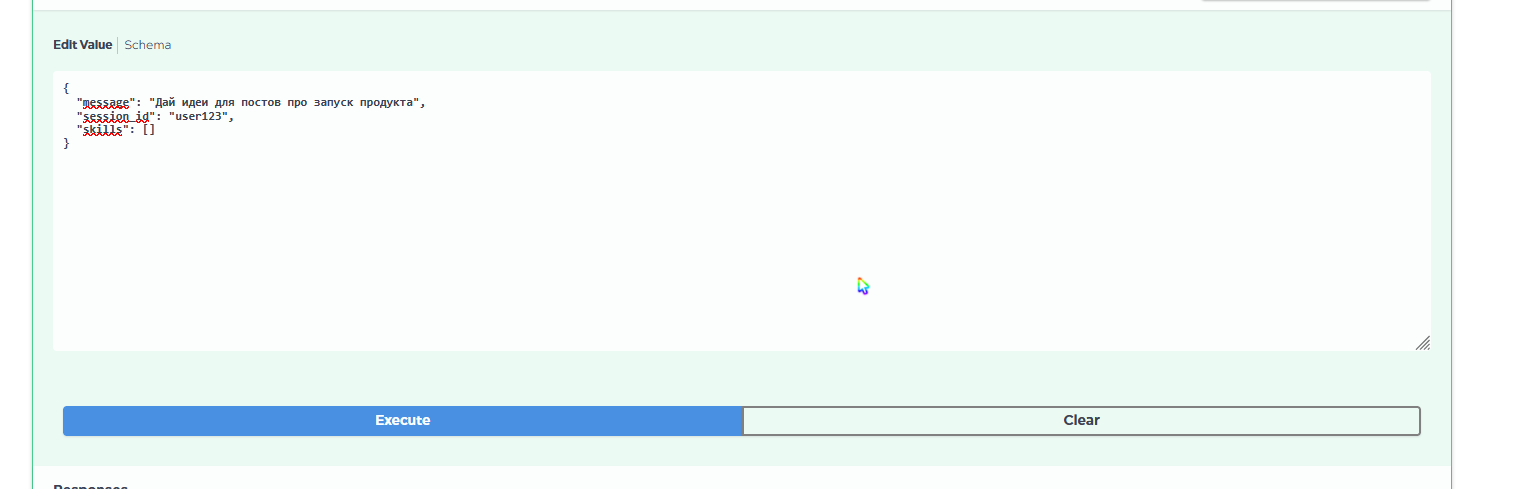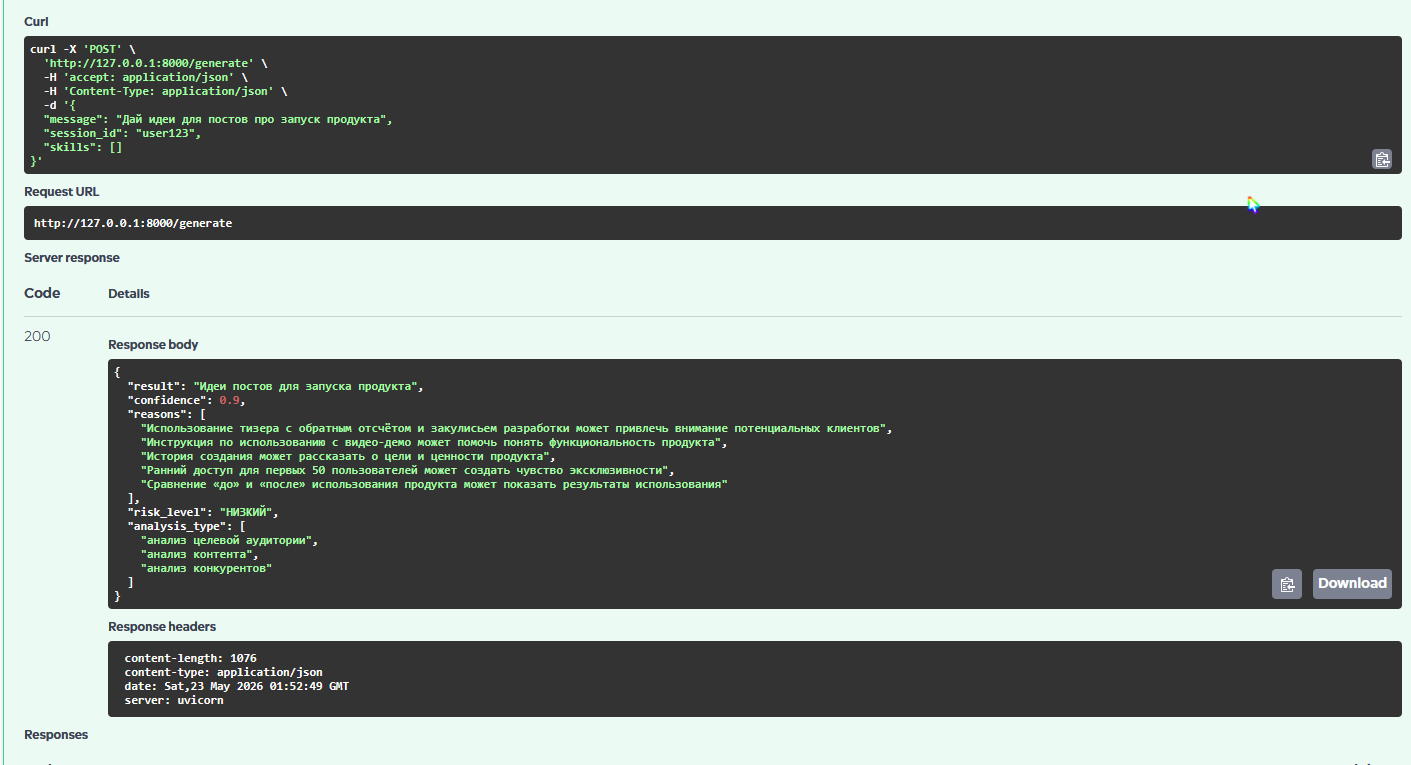

# С mcp не разобрался :(